In [182]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from tqdm import tqdm
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_paper/"
res_DIR = "../data/results_paper/"
resistance_DIR = "../data/resistance/"
%matplotlib widget

In [183]:
parameter_values = get_parameter_values()

spm = pybamm.lithium_ion.SPM(
    {
        "SEI": "ec reaction limited",
        "loss of active material": "stress-driven",
        "lithium plating": "irreversible",
        "stress-induced diffusion": "false",
    }
)
# spm.print_parameter_info()
param=spm.param

In [184]:
cell = 9
# sim_des = sim_des+'_cv'
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
Ns = np.insert(N[1:]-1,0,0)
eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe_0,spm,parameter_values)

pybamm.set_logging_level("WARNING")
# pybamm.set_logging_level("NOTICE")
par_val = {}
sno = 0
par_val[0] = [5.6076e-08,6.7429e-07,1.02,1.4576e-08,-1.7447e-07,-2.5257e-08]

parameter_values = get_parameter_values()
parameter_values.update(
    {
        "Negative electrode active material volume fraction": eps_n_data,
        "Positive electrode active material volume fraction": eps_p_data,
        "Initial temperature [K]": 273.15+45,
        "Ambient temperature [K]": 273.15+45,
        "Positive electrode LAM constant proportional term [s-1]": par_val[sno][0],
        "Negative electrode LAM constant proportional term [s-1]": par_val[sno][1],
        "Positive electrode LAM constant proportional term 2 [s-1]": par_val[sno][5],
        "Negative electrode LAM constant proportional term 2 [s-1]": par_val[sno][4],
        "Positive electrode LAM constant exponential term": par_val[sno][2],
        "Negative electrode LAM constant exponential term": par_val[sno][2],
        "SEI kinetic rate constant [m.s-1]":  4.60788219e-16, #1.08494281e-16 , 
        "EC diffusivity [m2.s-1]": 4.56607447e-19,#8.30909086e-19,
        "SEI growth activation energy [J.mol-1]": 1.87422275e+04,#1.58777981e+04,
        "Lithium plating kinetic rate constant [m.s-1]": par_val[sno][3],
        "Initial inner SEI thickness [m]": 0e-09,
        "Initial outer SEI thickness [m]": 5e-09,
        "SEI resistivity [Ohm.m]": 25*30000.0,
        "Negative electrode partial molar volume [m3.mol-1]": 7e-06,
        "Negative electrode LAM min stress [Pa]": 0,
        "Negative electrode LAM max stress [Pa]": 0,
        "Positive electrode LAM min stress [Pa]": 0,
        "Positive electrode LAM max stress [Pa]": 0,
        "Negative electrode diffusion coefficient [m2.s-1]": 8e-14,
        "Positive electrode diffusion coefficient [m2.s-1]": 8e-15,
        # "Negative electrode critical stress [Pa]": 20e+06,
        # "Positive electrode critical stress [Pa]": 40e+06,
    },
    check_already_exists=False,
)
if cell == 15 or cell == 18:
    parameter_values.update(
        {
            "Negative electrode partial molar volume [m3.mol-1]":	0.747*7e-06,
        },
        check_already_exists=False,
    )

In [185]:
cell = 28
cell_no = f'{cell:02d}'
dfe=pd.read_csv(eSOH_DIR+"aging_param_cell_"+cell_no+".csv")

In [186]:
N = dfe.N.iloc[-1]

In [187]:
experiment = pybamm.Experiment(
    [
        ("Discharge at "+c_rate_d+dis_set,
        "Rest for 10 sec",
        "Charge at "+c_rate_c+" until 4.2V", 
        "Hold at 4.2V until C/100")
    ],
    # ] *40,
    termination="50% capacity",
#     cccv_handling="ode",
)

In [188]:
sols = []

In [189]:
parameter_values.update(
    {
        "Negative electrode LAM min stress [Pa]": 0,
        "Negative electrode LAM max stress [Pa]": 0,
        "Positive electrode LAM min stress [Pa]": 0,
        "Positive electrode LAM max stress [Pa]": 0,

    },
    check_already_exists=False,
)
sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol1 = sim_long.solve(initial_soc=1)
sigma_ts_n = sol1["X-averaged negative particle surface tangential stress [Pa]"].entries
sigma_rs_n = sol1["X-averaged negative particle surface radial stress [Pa]"].entries
sigma_hs_n = (sigma_rs_n+2*sigma_ts_n)/2
sigma_ts_p = sol1["X-averaged positive particle surface tangential stress [Pa]"].entries
sigma_rs_p = sol1["X-averaged positive particle surface radial stress [Pa]"].entries
sigma_hs_p = (sigma_rs_p+2*sigma_ts_p)/2
parameter_values.update(
    {
        "Negative electrode LAM min stress [Pa]": min(sigma_hs_n),
        "Negative electrode LAM max stress [Pa]": max(sigma_hs_n),
        "Positive electrode LAM min stress [Pa]": min(sigma_hs_p),
        "Positive electrode LAM max stress [Pa]": max(sigma_hs_p),

    },
    check_already_exists=False,
)
sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol2 = sim_long.solve(initial_soc=1)
spm.set_initial_conditions_from(sol2, inplace=True)
sols.append(sol2)

In [190]:
for i in tqdm(range(N-1)):
    parameter_values.update(
        {
            "Negative electrode LAM min stress [Pa]": 0,
            "Negative electrode LAM max stress [Pa]": 0,
            "Positive electrode LAM min stress [Pa]": 0,
            "Positive electrode LAM max stress [Pa]": 0,

        },
        check_already_exists=False,
    )
    sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                                solver=pybamm.CasadiSolver("safe"))
    sol1 = sim_long.solve()
    sigma_ts_n = sol1["X-averaged negative particle surface tangential stress [Pa]"].entries
    sigma_rs_n = sol1["X-averaged negative particle surface radial stress [Pa]"].entries
    sigma_hs_n = (sigma_rs_n+2*sigma_ts_n)/2
    sigma_ts_p = sol1["X-averaged positive particle surface tangential stress [Pa]"].entries
    sigma_rs_p = sol1["X-averaged positive particle surface radial stress [Pa]"].entries
    sigma_hs_p = (sigma_rs_p+2*sigma_ts_p)/2
    parameter_values.update(
        {
            "Negative electrode LAM min stress [Pa]": min(sigma_hs_n),
            "Negative electrode LAM max stress [Pa]": max(sigma_hs_n),
            "Positive electrode LAM min stress [Pa]": min(sigma_hs_p),
            "Positive electrode LAM max stress [Pa]": max(sigma_hs_p),

        },
        check_already_exists=False,
    )
    sim_long = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values, 
                                solver=pybamm.CasadiSolver("safe"))
    sol2 = sim_long.solve()
    spm.set_initial_conditions_from(sol2, inplace=True)
    sols.append(sol2)

100%|██████████| 168/168 [13:03<00:00,  4.66s/it]


In [191]:
with open('hot_sim_2C_5psi_1.pickle', 'wb') as handle:
        pickle.dump(sols, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [192]:
cell = 9
cell_no = f'{cell:02d}'
dfe=pd.read_csv(eSOH_DIR+"aging_param_cell_cyc_"+cell_no+".csv")
cell = 28
cell_no = f'{cell:02d}'
dfe1=pd.read_csv(eSOH_DIR+"aging_param_cell_cyc_"+cell_no+".csv")

In [193]:
Qappd = []
Qappc = []
for i in range(len(sols)):
    sol_long = sols[i]
    Q = -sol_long['Discharge capacity [A.h]'].entries
    Q1 = -min(Q)
    Q2 = Q[-1]-min(Q)
    Qappd.append(Q1)
    Qappc.append(Q2)

In [194]:
Rs = []
for i in range(len(sols)):
    sol_long = sols[i]
    Vt = sol_long["Terminal voltage [V]"].entries
    R = (4.2-Vt[0])/(2*5)
    Rs.append(R)

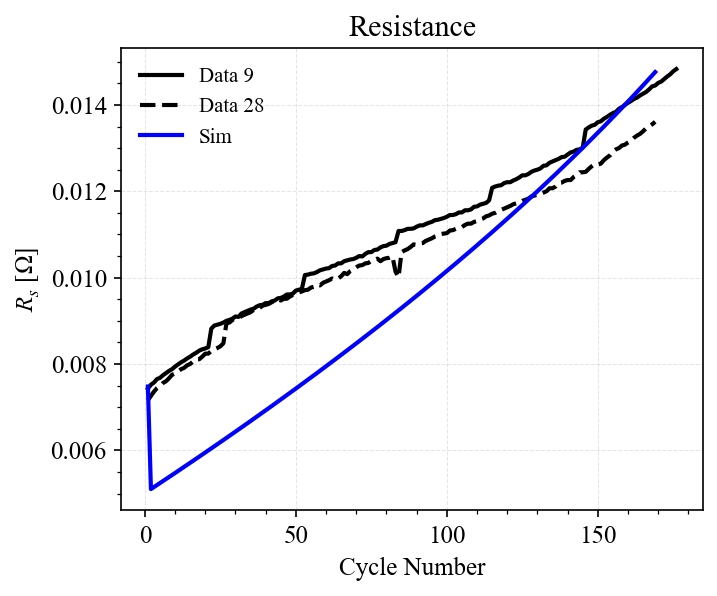

In [195]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe['N'],dfe['Rs [ohm]'],'k')
ax.plot(dfe1['N'],dfe1['Rs [ohm]'],'k--')
ax.plot(range(1,len(sols)+1),Rs,'b')
ax.set_title("Resistance")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$R_s$ [$\Omega$]")
ax.legend(['Data 9','Data 28','Sim'])
plt.savefig(fig_DIR + "Hot Resistance Sim.png")

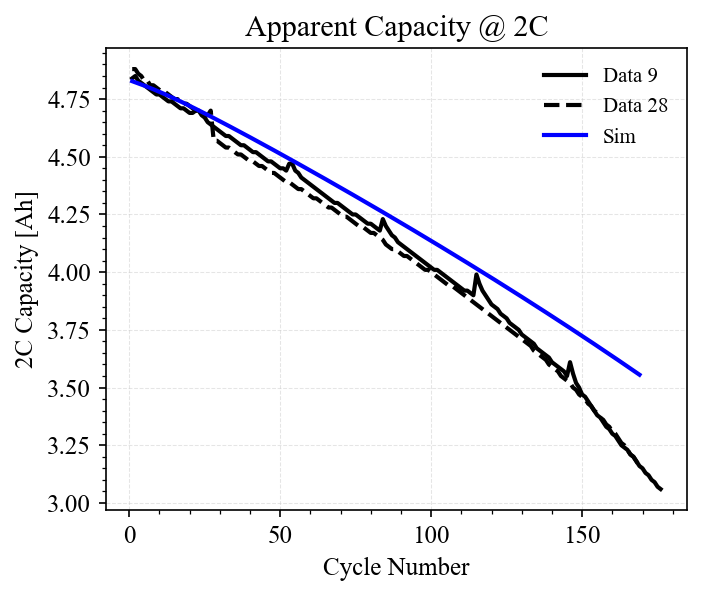

In [196]:
fig, ax = plt.subplots(1,1, sharex=True, figsize=(5,4))
ax.plot(dfe['N'],dfe['App Cap [Ah]'],'k')
ax.plot(dfe1['N'],dfe1['App Cap [Ah]'],'k--')
ax.plot(range(1,len(sols)+1),Qappd,'b')
# ax.plot(range(1,len(sols)+1),Qappc,'r')
ax.set_title("Apparent Capacity @ 2C")
ax.set_xlabel("Cycle Number")
ax.set_ylabel("2C Capacity [Ah]")
ax.legend(['Data 9','Data 28','Sim'])
plt.savefig(fig_DIR + "Hot Capacity Sim.png")

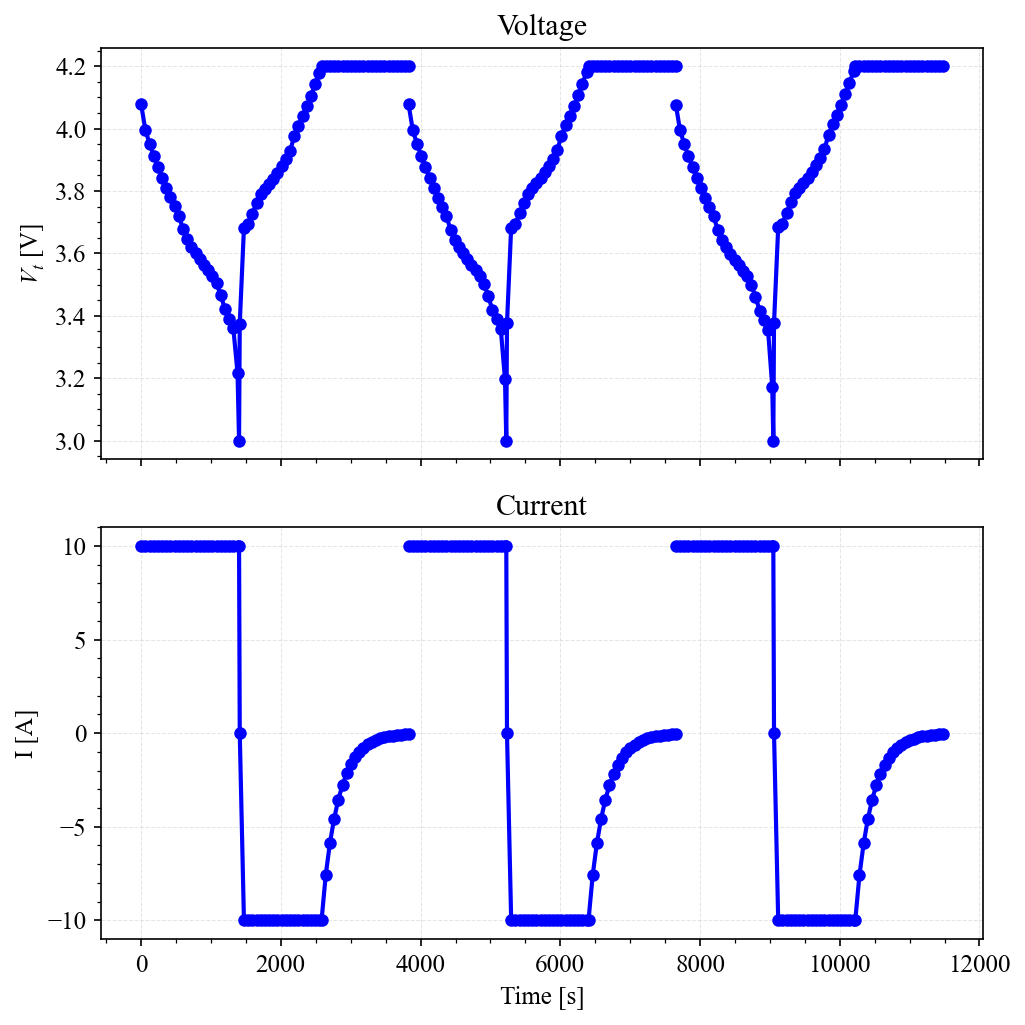

In [197]:
t1 = 0
fig, ax = plt.subplots(2,1, sharex=True, figsize=(7,7))
for i in range(132,135):
    sol_long = sols[i]
    t = sol_long["Time [s]"].entries + t1
    t1 = t[-1]
    I = sol_long["Current [A]"].entries
    Q = -sol_long['Discharge capacity [A.h]'].entries
    Vt = sol_long["Terminal voltage [V]"].entries
    I_Li = sol_long["X-averaged lithium plating interfacial current density [A.m-2]"].entries
    Q_Li = sol_long["Loss of capacity to lithium plating [A.h]"].entries
    ax1 = ax.flat[0]
    ax1.plot(t,Vt,'bo-')
    ax1.set_title("Voltage")
    ax1.set_ylabel(r"$V_t$ [V]")
    ax2 = ax.flat[1]
    ax2.plot(t,I,'bo-')
    ax2.set_title("Current")
    ax2.set_ylabel("I [A]")
    ax2.set_xlabel("Time [s]")
fig.tight_layout()
plt.savefig(fig_DIR +"Last 3 Cycles.png")

In [198]:
t_in0 = 10
t_in1 = 10
t_inf = t_in0+t_in1
t_in = np.arange(0,t_inf,0.1)
# t_in = np.arange(0,t_inf,1)
# t_sim = np.arange(0,t_inf,0.01)
I_in = []
for tt in t_in:
    if tt<t_in0:
        I_in = np.append(I_in,0)
    elif tt>=t_in0 and tt<t_in0+t_in1:
        I_in = np.append(I_in,-10)
# I_in = np.array([0,0,5,5,0,0,-5,-5,0,0])

In [199]:
sol_eol = sols[100]
SOC = 1
eSOH = sol_eol.all_summary_variables
eSOH = eSOH[0]
Vmin = 3.0
Vmax = 4.2
esoh_model = pybamm.lithium_ion.ElectrodeSOH()
esoh_sim = pybamm.Simulation(esoh_model, parameter_values=parameter_values)
Cn = eSOH["C_n"]
    # print(Cn)
Cp = eSOH["C_p"]
c_n_max = parameter_values.evaluate(param.n.prim.c_max)
c_p_max = parameter_values.evaluate(param.p.prim.c_max)
eps_n_data = parameter_values.evaluate(Cn*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
eps_p_data = parameter_values.evaluate(Cp*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))
del_sei = eSOH['X-averaged SEI thickness [m]']
c_lip = eSOH['X-averaged lithium plating concentration [mol.m-3]']
n_Li_init = eSOH["Total lithium in particles [mol]"]
esoh_sol = esoh_sim.solve(
    [0],
    inputs={"V_min": Vmin, "V_max": Vmax, "C_n": Cn, "C_p": Cp, "n_Li": n_Li_init},
    solver=pybamm.AlgebraicSolver(),
)
parameter_values.update(
        {
            "Negative electrode active material volume fraction": eps_n_data,
            "Positive electrode active material volume fraction": eps_p_data,
            "Initial temperature [K]": 273.15+45,
            "Ambient temperature [K]": 273.15+45,
            "Initial inner SEI thickness [m]": 0e-09,
            "Initial outer SEI thickness [m]": del_sei,
            "Initial plated lithium concentration [mol.m-3]": c_lip,
            "SEI resistivity [Ohm.m]": 25*30000.0,
        },
        check_already_exists=False,
    )
timescale = parameter_values.evaluate(spm.timescale)
current_interpolant = pybamm.Interpolant(
t_in, -I_in, timescale * pybamm.t
)
parameter_values["Current function [A]"] = current_interpolant
SOC_vals = np.linspace(1,0,11)
Rs_ch_s = []

c_n_max = parameter_values.evaluate(param.n.prim.c_max)
c_p_max = parameter_values.evaluate(param.p.prim.c_max)
x_100 = esoh_sol["x_100"].data[0]
y_100 = esoh_sol["y_100"].data[0]
x_0 = esoh_sol["x_0"].data[0]
y_0 = esoh_sol["y_0"].data[0]
cs_n_0 = (SOC*(x_100-x_0)+x_0)*c_n_max
cs_p_0 = (SOC*(y_100-y_0)+y_0)*c_p_max
parameter_values.update(
    {
        "Initial concentration in negative electrode [mol.m-3]": cs_n_0,
        "Initial concentration in positive electrode [mol.m-3]": cs_p_0,        
    },
    check_already_exists=False,
)

In [200]:
sim_pulse = pybamm.Simulation(spm, parameter_values=parameter_values, 
                        solver=pybamm.CasadiSolver(mode="safe", rtol=1e-6, atol=1e-6,dt_max=0.1))
sol_pulse = sim_pulse.solve(t_eval=t_in)
t   =  sol_pulse["Time [s]"].entries
I   =  sol_pulse["Current [A]"].entries
Vt  =  sol_pulse["Terminal voltage [V]"].entries
idx = np.where(np.diff(np.sign(-I)))[0]
Rs = abs((Vt[idx+1]-Vt[idx])/(I[idx+1]-I[idx]))[0]
sol_pulse2 = sol_pulse

In [201]:
t2 = sol_pulse2['Time [s]'].entries
seif_pot2 = sol_pulse2['X-averaged SEI film overpotential [V]'].entries
ocv_n2 = sol_pulse2['X-averaged negative electrode open circuit potential [V]'].entries
eta_n2 = sol_pulse2['X-averaged negative electrode reaction overpotential [V]'].entries
ocv_p2 = sol_pulse2['X-averaged positive electrode open circuit potential [V]'].entries
eta_p2 = sol_pulse2['X-averaged positive electrode reaction overpotential [V]'].entries
Vt2 = sol_pulse2["Terminal voltage [V]"].entries

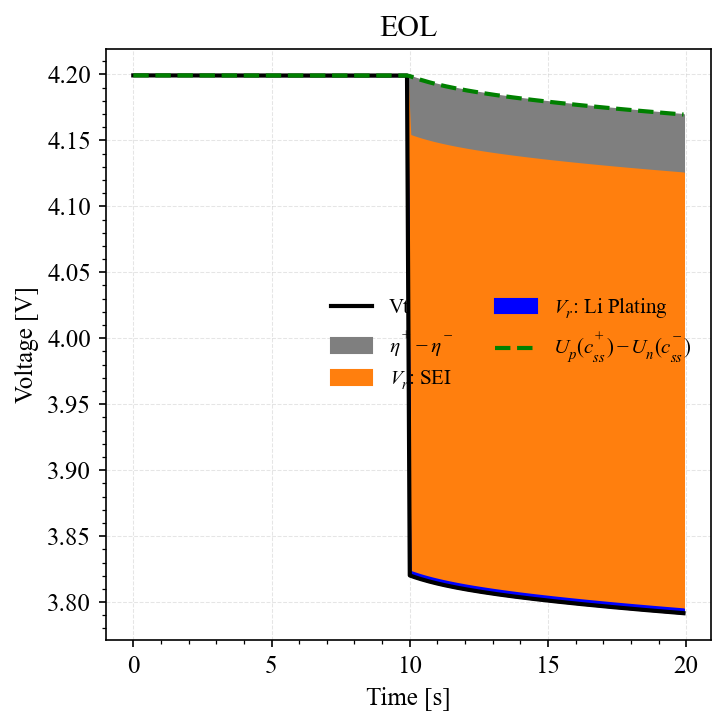

In [202]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
ax2 = ax
ax2.plot(t2,Vt2,'k')
ax2.fill_between(t2, ocv_p2-ocv_n2, ocv_p2+eta_p2-ocv_n2-eta_n2,color='tab:gray')
ax2.fill_between(t2,ocv_p2+eta_p2-ocv_n2-eta_n2,Vt2,color='tab:orange')
ax2.fill_between(t2,ocv_p2+eta_p2-ocv_n2-eta_n2+seif_pot2,Vt2,color='blue')
ax2.plot(t2,ocv_p2-ocv_n2,'g--')
# ax2.set_ylim([min(Vt2)-0.01,min(Vt2)+0.1])
ax2.set_title("EOL")
# ax2.yaxis.set_tick_params(labelleft=False)
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Voltage [V]")
ax2.legend(["Vt",r'$\eta^+-\eta^-$',r'$V_r$: SEI',r'$V_r$: Li Plating',r"$U_p(c^+_{ss})-U_n(c^-_{ss})$"],ncol=2)
fig.tight_layout()
# ax.set_xlim(left=2296)
# plt.savefig(fig_DIR +'lithium_plating_resistance.png')


In [203]:
(Vt[0]-4.11)/10

0.008924623387716402

In [204]:
Vt[0]-0.011*10

4.089246233877164

In [205]:
seif_pot2_scaled = [seip*25 for seip in seif_pot2]

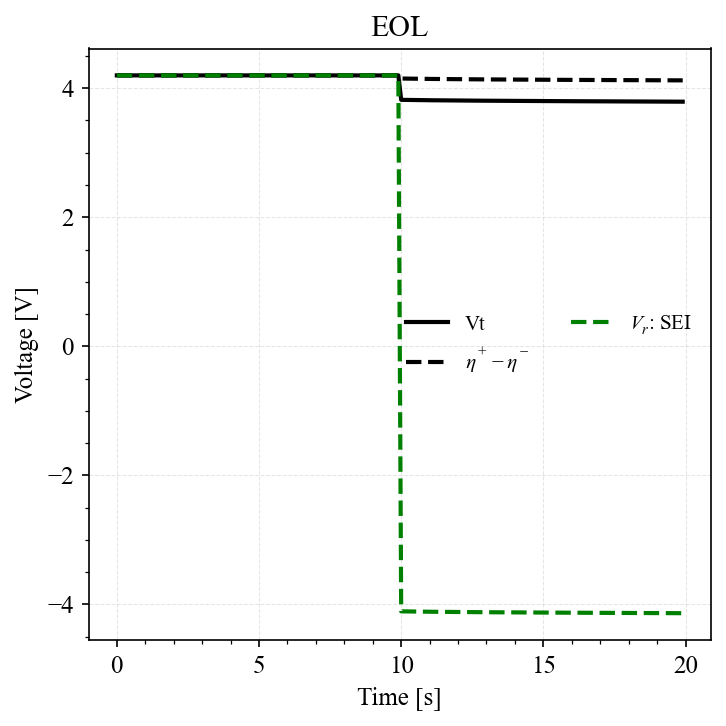

In [206]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
ax2 = ax
ax2.plot(t2,Vt2,'k')
ax2.plot(t2,Vt2-seif_pot2,'k--')
ax2.plot(t2,Vt2-seif_pot2+seif_pot2_scaled,'g--')
# ax2.set_ylim([min(Vt2)-0.01,min(Vt2)+0.1])
ax2.set_title("EOL")
# ax2.yaxis.set_tick_params(labelleft=False)
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Voltage [V]")
ax2.legend(["Vt",r'$\eta^+-\eta^-$',r'$V_r$: SEI',r'$V_r$: Li Plating',r"$U_p(c^+_{ss})-U_n(c^-_{ss})$"],ncol=2)
fig.tight_layout()
# ax.set_xlim(left=2296)
# plt.savefig(fig_DIR +'lithium_plating_resistance.png')
